# Finding Heavy Traffic Indicators on I-94

In this project, we'll analyze traffic volume data for westbound traffic on the [I-94 Interstate highway](https://en.wikipedia.org/wiki/Interstate_94), recorded by a station located between Minneapolis and Saint Paul. The dataset includes traffic volume along with weather, date, and time information, which allows us to explore patterns linked to heavier traffic.

John Hogue made the dataset available, and you can download it from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume).


| Variable Name       | Role    | Type        | Description                                                      | Units  |
| ------------------- | ------- | ----------- | ---------------------------------------------------------------- | ------ |
| holiday             | Feature | Categorical | US National holidays plus regional holiday, Minnesota State Fair |        |
| temp                | Feature | Continuous  | Average temp in kelvin                                           | Kelvin |
| rain_1h             | Feature | Continuous  | Amount in mm of rain that occurred in the hour                   | mm     |
| snow_1h             | Feature | Continuous  | Amount in mm of snow that occurred in the hour                   | mm     |
| clouds_all          | Feature | Integer     | Percentage of cloud cover                                        | %      |
| weather_main        | Feature | Categorical | Short textual description of the current weather                 |        |
| weather_description | Feature | Categorical | Longer textual description of the current weather                |        |
| date_time           | Feature | Date        | Hour of the data collected in local CST time                     |        |
| traffic_volume      | Target  | Integer     | Hourly I-94 ATR 301 reported westbound traffic volume            |        |


Our goal is to identify a few indicators that may help explain when traffic becomes heavy, such as the time of day, day of the week, month, or weather conditions. For instance, we may find out that the traffic is usually heavier in the summer or when it snows. 

The [dataset documentation](https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume) mentions that a station located approximately midway between Minneapolis and Saint Paul recorded the traffic data. Also, the station only records westbound traffic (cars moving from east to west).

![img](https://s3.amazonaws.com/dq-content/524/i94_figma.png)

Because the data only covers westbound traffic near one station, our conclusions will focus on that specific stretch of I-94 rather than the entire interstate highway.

# Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

metro = pd.read_csv(r"C:\Users\ntxhi\Downloads\Metro_Interstate_Traffic_Volume.csv",
                    parse_dates=['date_time'])

In [2]:
print(f"This dataset has {metro.shape[0]} rows and {metro.shape[1]} columns.")
print("Each row describes traffic and weather data for a specific hour — we have data from 2012-10-02 09:00:00 until 2018-09-30 23:00:00.")

This dataset has 48204 rows and 9 columns.
Each row describes traffic and weather data for a specific hour — we have data from 2012-10-02 09:00:00 until 2018-09-30 23:00:00.


In [3]:
metro.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
metro.tail()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


In [5]:
metro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     object        
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


In [6]:
# Check missing values in each columns
metro_na = metro.isna().sum() / len(metro) * 100.0


# Count no of columns having missing values
print(f"There are {metro_na[metro_na > 0].count()} columns have missing values")
print(metro_na[metro_na > 0])


# Count no of columns do not have missing values
print(f"\nAnd {metro_na[metro_na == 0].count()} columns do not have missing values.")
metro_na[metro_na == 0].index.to_list()

There are 1 columns have missing values
holiday    99.873454
dtype: float64

And 8 columns do not have missing values.


['temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_main',
 'weather_description',
 'date_time',
 'traffic_volume']

# Explore Data

## Analyzing Traffic Volume

We're going to start our analysis by examining the distribution of the `traffic_volume` column.

In [7]:
metro.describe()

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,2016-01-05 10:46:16.773711616,3259.818355
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014-02-06 11:45:00,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,2016-06-11 03:30:00,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,2017-08-11 06:00:00,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000
std,13.338232,44.789133,0.008168,39.015750,NaN,1986.860670


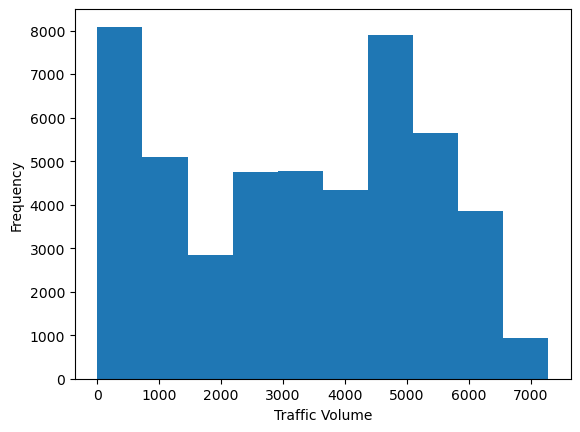

In [8]:
metro['traffic_volume'].plot.hist()
plt.xlabel('Traffic Volume')
plt.show()

The histogram shows the distribution of traffic volume over about 6 years, from October 2012 to September 2018. The values on the x-axis range from approximately 0 to 7,280 cars per hour, with an average of 3,260 cars. Most of the traffic volume values are concentrated between 3,000 and 6,000 cars per hour.

The distribution does not look normal or uniform. Instead, it seems to have two common areas: one around very low traffic volume, near 0, and another around 5,000 cars per hour. This suggests that traffic volume changes a lot depending on the time of day, with some periods having very light traffic and other periods having much heavier traffic. Specifically:
- About 25% of the time, there were 1,193 cars or fewer passing the station each hour — this probably occurs during the night, or when a road is under construction.
- About 75% of the time, the traffic volume was 4,933 cars or fewer. The remaining 25% of the time, the traffic volume exceeded 4,933 cars. This possibility that nighttime and daytime might influence traffic volume gives our analysis an interesting direction: comparing daytime with nighttime data.

Overall, the histogram suggests that traffic on westbound I-94 is often either very light or moderately heavy, while extremely high traffic volumes around 7,000 cars per hour are less common.

## Traffic Volume: Day vs. Night

This observation gives our analysis an interesting direction: comparing daytime data with nighttime data.

For further analysis, we'll start by dividing the dataset into two parts:

- Daytime data: hours from 7 a.m. to 7 p.m. (12 hours)
- Nighttime data: hours from 7 p.m. to 7 a.m. (12 hours)

While this is not a perfect criterion for distinguishing between nighttime and daytime, it's a good starting point.


In [9]:
day = metro[metro['date_time'].dt.hour.between(7, 18)].copy()
day

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.00,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.00,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.00,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.00,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.00,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48194,NaN,283.84,0.00,0.0,75,Rain,proximity shower rain,2018-09-30 15:00:00,4302
48195,NaN,283.84,0.00,0.0,75,Drizzle,light intensity drizzle,2018-09-30 15:00:00,4302
48196,NaN,284.38,0.00,0.0,75,Rain,light rain,2018-09-30 16:00:00,4283
48197,NaN,284.79,0.00,0.0,75,Clouds,broken clouds,2018-09-30 17:00:00,4132


In [10]:
night = metro[metro['date_time'].dt.hour.between(0,6) | 
              metro['date_time'].dt.hour.between(19,23)].copy()
night

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
10,NaN,290.97,0.0,0.0,20,Clouds,few clouds,2012-10-02 19:00:00,3539
11,NaN,289.38,0.0,0.0,1,Clear,sky is clear,2012-10-02 20:00:00,2784
12,NaN,288.61,0.0,0.0,1,Clear,sky is clear,2012-10-02 21:00:00,2361
13,NaN,287.16,0.0,0.0,1,Clear,sky is clear,2012-10-02 22:00:00,1529
14,NaN,285.45,0.0,0.0,1,Clear,sky is clear,2012-10-02 23:00:00,963
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


This significant difference in row numbers between `day` and `night` is due to a few hours of missing data. For instance, if you look at rows 176 and 177 (`i_94.iloc[176:178]`), you'll notice there's no data for two hours (4 and 5).

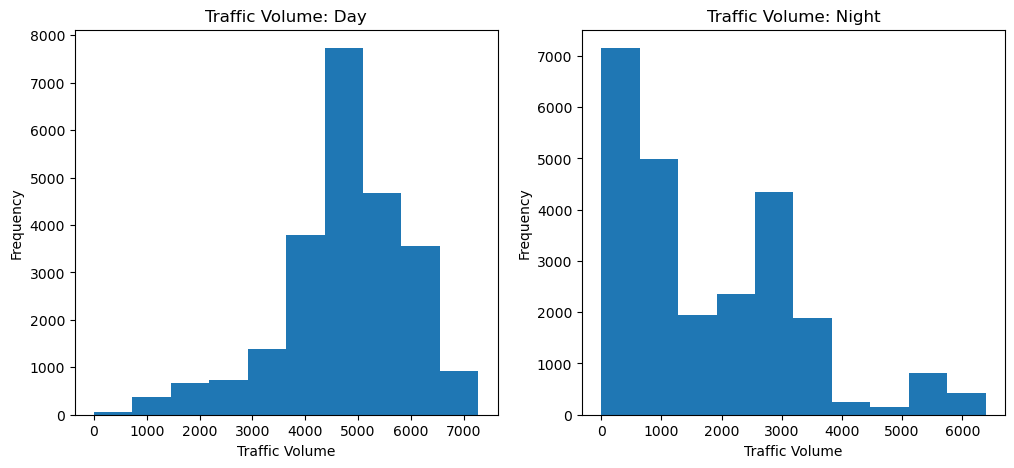

In [11]:
plt.figure(figsize=(12, 5))

titles = ['Traffic Volume: Day', 'Traffic Volume: Night']

for i, time, title in zip(range(1, 3), [day, night], titles):
    plt.subplot(1, 2, i)
    plt.hist(time['traffic_volume'])
    plt.title(title)
    plt.xlabel('Traffic Volume')
    plt.ylabel('Frequency')

plt.show()

In [12]:
day['traffic_volume'].describe()

count    23877.000000
mean      4762.047452
std       1174.546482
min          0.000000
25%       4252.000000
50%       4820.000000
75%       5559.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [13]:
night['traffic_volume'].describe()

count    24327.000000
mean      1785.377441
std       1441.951197
min          0.000000
25%        530.000000
50%       1287.000000
75%       2819.000000
max       6386.000000
Name: traffic_volume, dtype: float64

The histogram that shows the distribution of traffic volume during the day is left skewed. This means that most of the traffic volume values are high — there are 4,252 or more cars passing the station each hour 75% of the time (because 25% of values are less than 4,252).

The histogram displaying the nighttime data is right skewed. This means that most of the traffic volume values are low — 75% of the time, the number of cars that passed the station each hour was less than 2,819.

Although there are still measurements of over 5,000 cars per hour, the traffic at night is generally light. Our goal is to find indicators of heavy traffic, so we'll only focus on the daytime data moving forward.

## Time Indicators

We determined that the traffic at night is generally light. Our goal is to find indicators of heavy traffic, so we decided to only focus on the daytime data moving forward.

One of the possible indicators of heavy traffic is time. There might be more people on the road in a certain month, on a certain day, or at a certain time of the day.

We're going to look at a few line plots showing how the traffic volume changed according to the following parameters:

- Month
- Day of the week
- Time of day

### Traffic Volume per Month

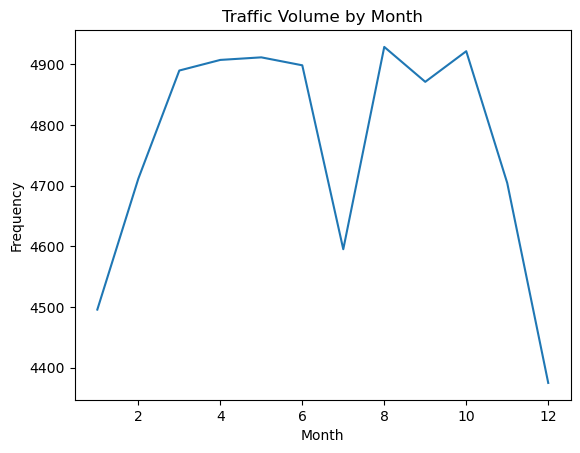

In [14]:
day['month'] = day['date_time'].dt.month
by_month = day.groupby('month').mean(numeric_only=True)
by_month['traffic_volume'].plot.line()
plt.title("Traffic Volume by Month")
plt.xlabel("Month")
plt.ylabel("Frequency")
plt.show()

The traffic looks less heavy during cold months (November–February) and more intense during warm months (March–October), with one interesting exception: July. Is there anything special about July? Is traffic significantly less heavy in July each year?

### Traffic Volume July only

To answer the above question, let's see how the traffic volume changed each year in July.

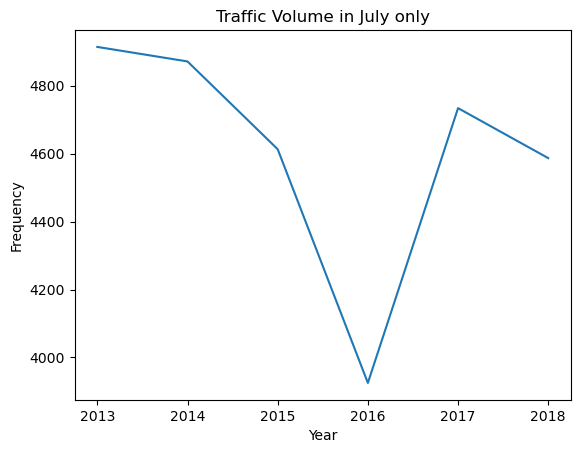

In [15]:
day['year'] = day['date_time'].dt.year
only_july = day[day['month'] == 7]
only_july.groupby('year').mean(numeric_only=True)['traffic_volume'].plot.line()
plt.title("Traffic Volume in July only")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

Typically, the traffic is pretty heavy in July, similar to the other warm months. The only exception we see is 2016, which had a high decrease in traffic volume. One possible reason for this is road construction — [this article from 2016](https://www.crainsdetroit.com/article/20160728/NEWS/160729841/weekend-construction-i-96-us-23-bridge-work-i-94-lane-closures-i-696) supports this hypothesis.

As a tentative conclusion here, we can say that warm months generally show heavier traffic compared to cold months. In a warm month, you can can expect for each hour of daytime a traffic volume close to 5,000 cars.

### Traffic Volume: Day of Week

Let's now look at a more granular indicator: day number.

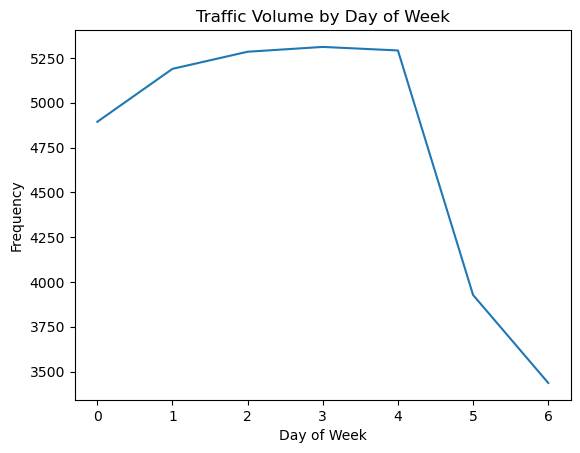

In [16]:
day['dayofweek'] = day['date_time'].dt.dayofweek
by_dayofweek = day.groupby('dayofweek').mean(numeric_only=True)
by_dayofweek['traffic_volume'].plot.line()  # 0 is Monday, 6 is Sunday
plt.title("Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Frequency")
plt.show()

Traffic volume is significantly heavier on business days (Monday – Friday). Except for Monday, we only see values over 5,000 during business days. Traffic is lighter on weekends, with values below 4,000 cars.

### Traffic Volume: Weekday vs. Weekend

We found that the traffic volume is significantly heavier on business days compared to the weekends.

We'll now generate a line plot for the time of day. The weekends, however, will drag down the average values, so we're going to look at the averages separately. To do that, we'll start by splitting the data based on the day type: business day or weekend.

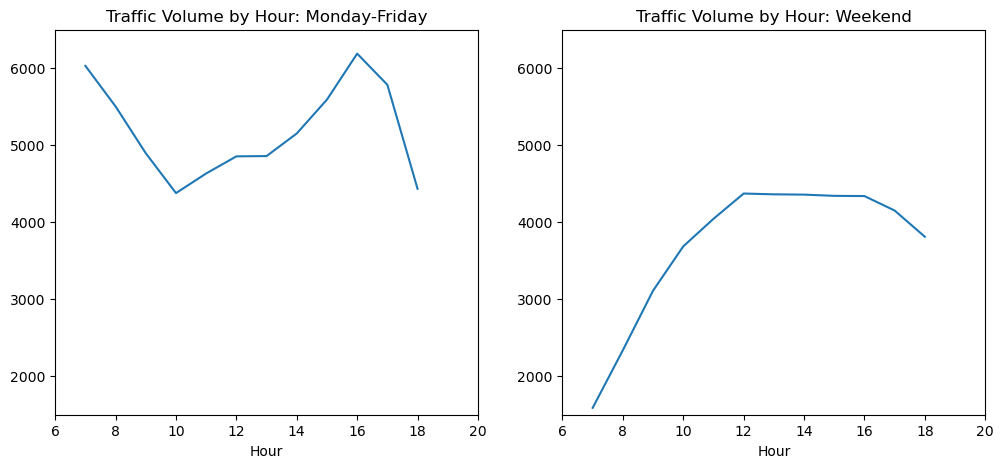

In [17]:
day['hour'] = day['date_time'].dt.hour
weekday = day.copy()[day['dayofweek'].between(0,4)] # 0 is Monday, 6 is Sunday
weekend = day.copy()[day['dayofweek'].between(5,6)]

by_hour_weekday = weekday.groupby('hour').mean(numeric_only=True)['traffic_volume']
by_hour_weekend = weekend.groupby('hour').mean(numeric_only=True)['traffic_volume']

plt.figure(figsize=(12,5))
for i, by_hour, title in zip(range(1,3), 
                             [by_hour_weekday, by_hour_weekend], 
                             ['Traffic Volume by Hour: Monday-Friday', 'Traffic Volume by Hour: Weekend']):
    plt.subplot(1, 2, i)
    plt.plot(by_hour)
    plt.xlabel('Hour')
    plt.xlim(6,20)
    plt.ylim(1500,6500)
    plt.title(title)

plt.show()

At each hour of the day, the traffic volume is generally higher during business days compared to the weekends. As somehow expected, the rush hours are around 7 and 16 — when most people travel from home to work and back. We see volumes of over 6,000 cars at rush hours.

To summarize, we found a few time-related indicators of heavy traffic:

- The traffic is usually heavier during warm months (March–October) compared to cold months (November–February).
- The traffic is usually heavier on business days compared to weekends.
- On business days, the rush hours are around 7 and 16.

## Weather Indicators

Another possible indicator of heavy traffic is weather. The dataset provides us with a few useful columns about weather: `temp`, `rain_1h`, `snow_1h`, `clouds_all`, `weather_main`, `weather_description`.

A few of these columns are numerical so let's start by looking up their correlation values with `traffic_volume`.

In [18]:
day.corr(numeric_only=True)['traffic_volume']


temp              0.128317
rain_1h           0.003697
snow_1h           0.001265
clouds_all       -0.032932
traffic_volume    1.000000
month            -0.022337
year             -0.003557
dayofweek        -0.416453
hour              0.172704
Name: traffic_volume, dtype: float64

Temperature shows the strongest correlation with a value of just +0.13. The other relevant columns (`rain_1h`, `snow_1h`, `clouds_all`) don't show any strong correlation with `traffic_value`.

Let's generate a scatter plot to visualize the correlation between `temp` and `traffic_volume`.

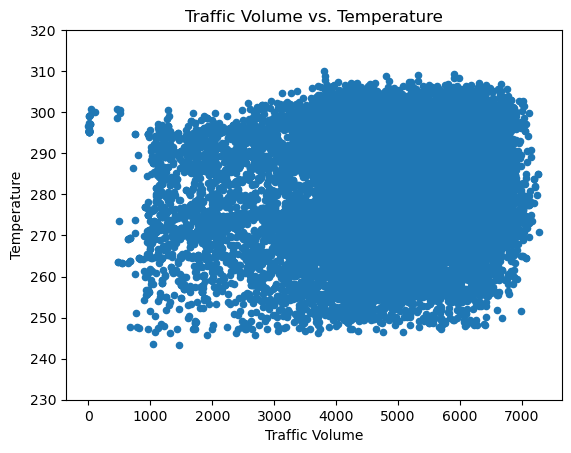

In [19]:
day.plot.scatter('traffic_volume', 'temp')
plt.xlabel("Traffic Volume")
plt.ylabel('Temperature')
plt.title("Traffic Volume vs. Temperature")
plt.ylim(230, 320) # two wrong 0K temperatures mess up the y-axis
plt.show()

We can conclude that temperature doesn't look like a solid indicator of heavy traffic.

Let's now look at the other weather-related columns: `weather_main` and `weather_description`.

### Weather Types

  To start, we're going to group the data by `weather_main` and look at the `traffic_volume` averages.

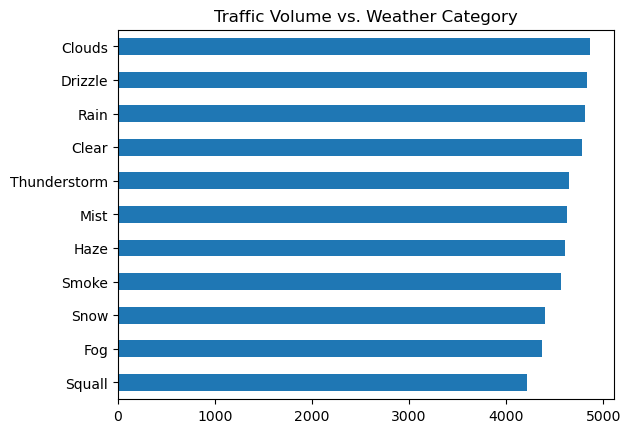

In [20]:
by_weather_main = day.groupby('weather_main').mean(numeric_only=True)
by_weather_main['traffic_volume'].sort_values().plot.barh().set_ylabel('')
plt.title('Traffic Volume vs. Weather Category')
plt.show()

It looks like there's no weather type where traffic volume exceeds 5,000 cars. This makes finding a heavy traffic indicator more difficult. Let's also group by `weather_description`, which has a more granular weather classification.

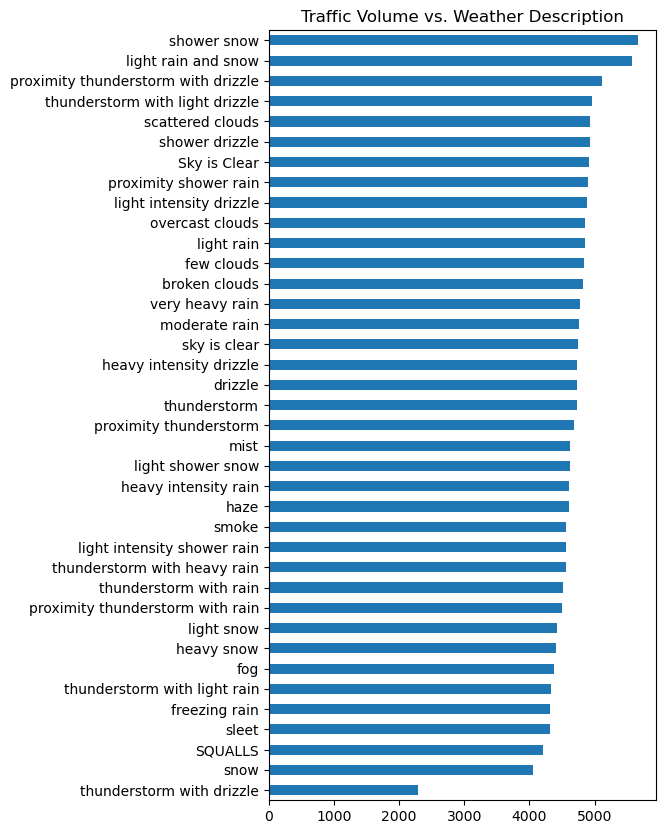

In [21]:
by_weather_description = day.groupby('weather_description').mean(numeric_only=True)
by_weather_description['traffic_volume'].sort_values().plot.barh(figsize=(5,10)).set_ylabel('')
plt.title('Traffic Volume vs. Weather Description')
plt.show()

It looks like there are three weather types where traffic volume exceeds 5,000:

- Shower snow
- Light rain and snow
- Proximity thunderstorm with drizzle

It's not clear why these weather types have the highest average traffic values — this is bad weather, but not that bad. Perhaps more people take their cars out of the garage when the weather is bad instead of riding a bike or walking.

# Conclusion

In this project, we tried to find a few indicators of heavy traffic on the I-94 Interstate highway. We managed to find two types of indicators:

- Time indicators
    - The traffic is usually heavier during warm months (March–October) compared to cold months (November–February).
    - The traffic is usually heavier on business days compared to the weekends.
    - On business days, the rush hours are around 7 and 16.
- Weather indicators
    - Shower snow
    - Light rain and snow
    - Proximity thunderstorm with drizzle